![图片描述](CNN_01.png)

## 数学公式

设输入矩阵为 $X \in \mathbb{R}^{H \times W}$，卷积核为 $K \in \mathbb{R}^{f \times f}$。

当步长 stride = 1、padding = 0 时，输出特征图 $Y$ 的大小为：

$$
H_{out} = H - f + 1,\qquad W_{out} = W - f + 1
$$

输出第 $(i,j)$ 个位置的值为：

$$
Y[i,j] = \sum_{m=0}^{f-1}\sum_{n=0}^{f-1} X[i+m,\;j+n]\cdot K[m,n]
$$

如果再加上偏置项 $b$：

$$
Y[i,j] = \sum_{m=0}^{f-1}\sum_{n=0}^{f-1} X[i+m,\;j+n]\cdot K[m,n] + b
$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

In [3]:
# 输入图像（5x5）
X = np.array([
    [9, 4, 1, 2, 2],
    [1, 1, 1, 0, 4],
    [1, 2, 1, 0, 6],
    [4, 0, 0, 2, 0],
    [9, 6, 7, 4, 3]
], dtype=float)

# Filter / Kernel（3x3）
K = np.array([
    [0, 2, 1],
    [4, 1, 0],
    [1, 0, 1]
], dtype=float)

print("Input image X =")
print(X)
print("\nFilter K =")
print(K)

Input image X =
[[9. 4. 1. 2. 2.]
 [1. 1. 1. 0. 4.]
 [1. 2. 1. 0. 6.]
 [4. 0. 0. 2. 0.]
 [9. 6. 7. 4. 3.]]

Filter K =
[[0. 2. 1.]
 [4. 1. 0.]
 [1. 0. 1.]]


## 先看输出尺寸

输入是 $5\times5$，filter 是 $3\times3$，stride = 1，padding = 0。

所以输出特征图大小为：

$$
(5-3+1)\times(5-3+1)=3\times3
$$

In [4]:
H, W = X.shape
f = K.shape[0]

H_out = H - f + 1
W_out = W - f + 1

print("Output feature map shape:", (H_out, W_out))

Output feature map shape: (3, 3)


In [ ]:
def conv2d_single_channel(X, K, bias=0.0, stride=1, padding=0):
    """
    Hyperparameters of a Convolutional Layer
    X: 输入矩阵，形状 (H, W)
    K: 卷积核，形状 (f, f)
    bias: 偏置
    stride: 步长
    padding: 零填充
    """
    X = np.asarray(X, dtype=float)
    K = np.asarray(K, dtype=float)

    # 1) padding
    if padding > 0:
        X_padded = np.pad(X, ((padding, padding), (padding, padding)), mode='constant')
    else:
        X_padded = X.copy()

    H, W = X_padded.shape
    f = K.shape[0]

    H_out = (H - f) // stride + 1
    W_out = (W - f) // stride + 1

    Y = np.zeros((H_out, W_out), dtype=float)

    # 2) 滑动窗口
    for i in range(H_out):
        for j in range(W_out):
            h_start = i * stride
            h_end   = h_start + f
            w_start = j * stride
            w_end   = w_start + f

            window = X_padded[h_start:h_end, w_start:w_end]
            Y[i, j] = np.sum(window * K) + bias

    return Y

In [6]:
Y = conv2d_single_channel(X, K, bias=0.0, stride=1, padding=0)

print("Feature map Y =")
print(Y)

Feature map Y =
[[16. 11. 17.]
 [13. 13.  8.]
 [37. 12. 18.]]


In [7]:
def explain_conv2d(X, K, bias=0.0, stride=1, padding=0):
    if padding > 0:
        X_padded = np.pad(X, ((padding, padding), (padding, padding)), mode='constant')
    else:
        X_padded = X.copy()

    H, W = X_padded.shape
    f = K.shape[0]
    H_out = (H - f) // stride + 1
    W_out = (W - f) // stride + 1

    Y = np.zeros((H_out, W_out), dtype=float)

    for i in range(H_out):
        for j in range(W_out):
            h_start = i * stride
            h_end   = h_start + f
            w_start = j * stride
            w_end   = w_start + f

            window = X_padded[h_start:h_end, w_start:w_end]
            prod = window * K
            value = np.sum(prod) + bias
            Y[i, j] = value

            print("=" * 60)
            print(f"Output Y[{i},{j}]")
            print("Window =")
            print(window)
            print("K =")
            print(K)
            print("Window * K =")
            print(prod)
            print(f"sum(Window * K) + bias = {np.sum(prod):.1f} + {bias:.1f} = {value:.1f}")

    return Y

_ = explain_conv2d(X, K)

Output Y[0,0]
Window =
[[9. 4. 1.]
 [1. 1. 1.]
 [1. 2. 1.]]
K =
[[0. 2. 1.]
 [4. 1. 0.]
 [1. 0. 1.]]
Window * K =
[[0. 8. 1.]
 [4. 1. 0.]
 [1. 0. 1.]]
sum(Window * K) + bias = 16.0 + 0.0 = 16.0
Output Y[0,1]
Window =
[[4. 1. 2.]
 [1. 1. 0.]
 [2. 1. 0.]]
K =
[[0. 2. 1.]
 [4. 1. 0.]
 [1. 0. 1.]]
Window * K =
[[0. 2. 2.]
 [4. 1. 0.]
 [2. 0. 0.]]
sum(Window * K) + bias = 11.0 + 0.0 = 11.0
Output Y[0,2]
Window =
[[1. 2. 2.]
 [1. 0. 4.]
 [1. 0. 6.]]
K =
[[0. 2. 1.]
 [4. 1. 0.]
 [1. 0. 1.]]
Window * K =
[[0. 4. 2.]
 [4. 0. 0.]
 [1. 0. 6.]]
sum(Window * K) + bias = 17.0 + 0.0 = 17.0
Output Y[1,0]
Window =
[[1. 1. 1.]
 [1. 2. 1.]
 [4. 0. 0.]]
K =
[[0. 2. 1.]
 [4. 1. 0.]
 [1. 0. 1.]]
Window * K =
[[0. 2. 1.]
 [4. 2. 0.]
 [4. 0. 0.]]
sum(Window * K) + bias = 13.0 + 0.0 = 13.0
Output Y[1,1]
Window =
[[1. 1. 0.]
 [2. 1. 0.]
 [0. 0. 2.]]
K =
[[0. 2. 1.]
 [4. 1. 0.]
 [1. 0. 1.]]
Window * K =
[[0. 2. 0.]
 [8. 1. 0.]
 [0. 0. 2.]]
sum(Window * K) + bias = 13.0 + 0.0 = 13.0
Output Y[1,2]
Window =
[[1. 0.

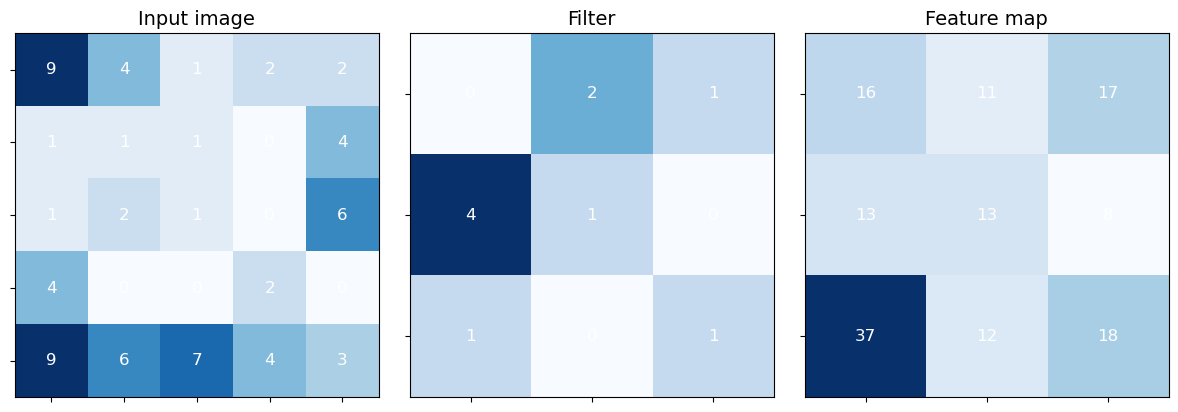

In [8]:
def draw_matrix(ax, M, title="", cmap="Blues", text_color="white"):
    ax.imshow(M, cmap=cmap)
    ax.set_title(title, fontsize=14)
    ax.set_xticks(range(M.shape[1]))
    ax.set_yticks(range(M.shape[0]))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.text(j, i, f"{M[i,j]:.0f}", ha="center", va="center", color=text_color, fontsize=12)
    ax.set_xlim(-0.5, M.shape[1]-0.5)
    ax.set_ylim(M.shape[0]-0.5, -0.5)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
draw_matrix(axes[0], X, title="Input image")
draw_matrix(axes[1], K, title="Filter")
draw_matrix(axes[2], Y, title="Feature map")
plt.tight_layout()
plt.show()

In [9]:
def compute_all_steps(X, K, bias=0.0, stride=1, padding=0):
    if padding > 0:
        X_padded = np.pad(X, ((padding, padding), (padding, padding)), mode='constant')
    else:
        X_padded = X.copy()

    H, W = X_padded.shape
    f = K.shape[0]
    H_out = (H - f) // stride + 1
    W_out = (W - f) // stride + 1

    steps = []
    Y = np.full((H_out, W_out), np.nan)

    for i in range(H_out):
        for j in range(W_out):
            h_start = i * stride
            h_end   = h_start + f
            w_start = j * stride
            w_end   = w_start + f

            window = X_padded[h_start:h_end, w_start:w_end]
            prod = window * K
            value = np.sum(prod) + bias
            Y[i, j] = value

            steps.append({
                "i": i,
                "j": j,
                "window": window.copy(),
                "prod": prod.copy(),
                "value": value,
                "Y_partial": Y.copy(),
                "h_start": h_start,
                "w_start": w_start
            })
    return steps

steps = compute_all_steps(X, K)
len(steps)

9

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
ax_in, ax_k, ax_out = axes

def setup_axes():
    draw_matrix(ax_in, X, title="Input image")
    draw_matrix(ax_k, K, title="Filter")
    ax_out.imshow(np.zeros((H_out, W_out)), cmap="Blues", vmin=0, vmax=np.nanmax(Y))
    ax_out.set_title("Feature map")
    ax_out.set_xticks(range(W_out))
    ax_out.set_yticks(range(H_out))
    ax_out.set_xticklabels([])
    ax_out.set_yticklabels([])
    ax_out.set_xlim(-0.5, W_out-0.5)
    ax_out.set_ylim(H_out-0.5, -0.5)

setup_axes()

def update(frame):
    for ax in axes:
        ax.clear()

    step = steps[frame]

    draw_matrix(ax_in, X, title=f"Input image\nwindow -> Y[{step['i']},{step['j']}]")
    rect = Rectangle((step["w_start"]-0.5, step["h_start"]-0.5), 3, 3,
                     fill=False, linewidth=3)
    ax_in.add_patch(rect)

    draw_matrix(ax_k, K, title="Filter")

    partial = step["Y_partial"]
    visible = np.nan_to_num(partial, nan=0.0)
    ax_out.imshow(visible, cmap="Blues", vmin=0, vmax=np.nanmax(Y))
    ax_out.set_title(f"Feature map\nY[{step['i']},{step['j']}] = {step['value']:.0f}")
    ax_out.set_xticks(range(W_out))
    ax_out.set_yticks(range(H_out))
    ax_out.set_xticklabels([])
    ax_out.set_yticklabels([])

    for i in range(H_out):
        for j in range(W_out):
            if not np.isnan(partial[i, j]):
                ax_out.text(j, i, f"{partial[i,j]:.0f}", ha="center", va="center",
                            color="white", fontsize=12)

    rect_out = Rectangle((step["j"]-0.5, step["i"]-0.5), 1, 1,
                         fill=False, linewidth=3)
    ax_out.add_patch(rect_out)

    plt.tight_layout()

anim = FuncAnimation(fig, update, frames=len(steps), interval=1200, repeat=True)

plt.close(fig)
HTML(anim.to_jshtml())

<Figure size 640x480 with 0 Axes>

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.8))
ax_in, ax_win, ax_k, ax_out = axes

def update_detail(frame):
    for ax in axes:
        ax.clear()

    step = steps[frame]

    draw_matrix(ax_in, X, title=f"Input image\nwindow -> Y[{step['i']},{step['j']}]")
    rect = Rectangle((step["w_start"]-0.5, step["h_start"]-0.5), 3, 3,
                     fill=False, linewidth=3)
    ax_in.add_patch(rect)

    draw_matrix(ax_win, step["prod"], title="Window * Filter = sum(items)")
    draw_matrix(ax_k, K, title="Filter")

    partial = step["Y_partial"]
    visible = np.nan_to_num(partial, nan=0.0)
    ax_out.imshow(visible, cmap="Blues", vmin=0, vmax=np.nanmax(Y))
    ax_out.set_title(f"Feature map\nvalue = {step['value']:.0f}")
    ax_out.set_xticks(range(W_out))
    ax_out.set_yticks(range(H_out))
    ax_out.set_xticklabels([])
    ax_out.set_yticklabels([])
    for i in range(H_out):
        for j in range(W_out):
            if not np.isnan(partial[i, j]):
                ax_out.text(j, i, f"{partial[i,j]:.0f}", ha="center", va="center",
                            color="white", fontsize=12)
    rect_out = Rectangle((step["j"]-0.5, step["i"]-0.5), 1, 1,
                         fill=False, linewidth=3)
    ax_out.add_patch(rect_out)

    plt.tight_layout()

anim2 = FuncAnimation(fig, update_detail, frames=len(steps), interval=1400, repeat=True)

plt.close(fig)
HTML(anim2.to_jshtml())

<Figure size 640x480 with 0 Axes>

In [12]:
def formula_for_position(X, K, out_i, out_j):
    f = K.shape[0]
    window = X[out_i:out_i+f, out_j:out_j+f]

    terms = []
    values = []
    for m in range(f):
        for n in range(f):
            a = window[m, n]
            b = K[m, n]
            terms.append(f"({int(a)}*{int(b)})")
            values.append(a * b)

    formula = " + ".join(terms)
    value_line = " + ".join(str(int(v)) for v in values)
    total = int(np.sum(values))

    print(f"Y[{out_i},{out_j}] = {formula}")
    print(f"          = {value_line}")
    print(f"          = {total}")
    print()

for i in range(Y.shape[0]):
    for j in range(Y.shape[1]):
        formula_for_position(X, K, i, j)

Y[0,0] = (9*0) + (4*2) + (1*1) + (1*4) + (1*1) + (1*0) + (1*1) + (2*0) + (1*1)
          = 0 + 8 + 1 + 4 + 1 + 0 + 1 + 0 + 1
          = 16

Y[0,1] = (4*0) + (1*2) + (2*1) + (1*4) + (1*1) + (0*0) + (2*1) + (1*0) + (0*1)
          = 0 + 2 + 2 + 4 + 1 + 0 + 2 + 0 + 0
          = 11

Y[0,2] = (1*0) + (2*2) + (2*1) + (1*4) + (0*1) + (4*0) + (1*1) + (0*0) + (6*1)
          = 0 + 4 + 2 + 4 + 0 + 0 + 1 + 0 + 6
          = 17

Y[1,0] = (1*0) + (1*2) + (1*1) + (1*4) + (2*1) + (1*0) + (4*1) + (0*0) + (0*1)
          = 0 + 2 + 1 + 4 + 2 + 0 + 4 + 0 + 0
          = 13

Y[1,1] = (1*0) + (1*2) + (0*1) + (2*4) + (1*1) + (0*0) + (0*1) + (0*0) + (2*1)
          = 0 + 2 + 0 + 8 + 1 + 0 + 0 + 0 + 2
          = 13

Y[1,2] = (1*0) + (0*2) + (4*1) + (1*4) + (0*1) + (6*0) + (0*1) + (2*0) + (0*1)
          = 0 + 0 + 4 + 4 + 0 + 0 + 0 + 0 + 0
          = 8

Y[2,0] = (1*0) + (2*2) + (1*1) + (4*4) + (0*1) + (0*0) + (9*1) + (6*0) + (7*1)
          = 0 + 4 + 1 + 16 + 0 + 0 + 9 + 0 + 7
          = 37

Y[2,1] = (2*0